In [1]:
from noawclg.main import get_noaa_data as gnd

In [6]:
data = gnd(date='06/04/2026')

In [4]:
data._ds['t2m'][1]

<xarray.DataArray 't2m' (latitude: 721, longitude: 1440)> Size: 8MB
array([[-22.14996948, -22.14996948, -22.14996948, ..., -22.14996948,
        -22.14996948, -22.14996948],
       [-20.44997253, -20.44997253, -20.44997253, ..., -20.44997253,
        -20.44997253, -20.44997253],
       [-24.34998169, -24.34998169, -24.34998169, ..., -24.44997253,
        -24.44997253, -24.34998169],
       ...,
       [-50.04997864, -50.04997864, -50.04997864, ..., -50.04997864,
        -50.04997864, -50.04997864],
       [-49.94997253, -49.94997253, -49.94997253, ..., -49.94997253,
        -49.94997253, -49.94997253],
       [-49.84998169, -49.84998169, -49.84998169, ..., -49.84998169,
        -49.84998169, -49.84998169]], shape=(721, 1440))
Coordinates:
    time           datetime64[ns] 8B 2026-04-06T03:00:00
  * latitude       (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude      (longitude) float64 12kB -179.8 -179.5 -179.2 ... 179.8 180.0
    forecast_hour  int64 8B 3
Attributes:
    long_name:  2 metre temperature
    units:      C
    gfs_run:    20260406 00Z

TypeError: Dimensions of C (69, 0) should be one smaller than X(0) and Y(70) while using shading='flat' see help(pcolormesh)

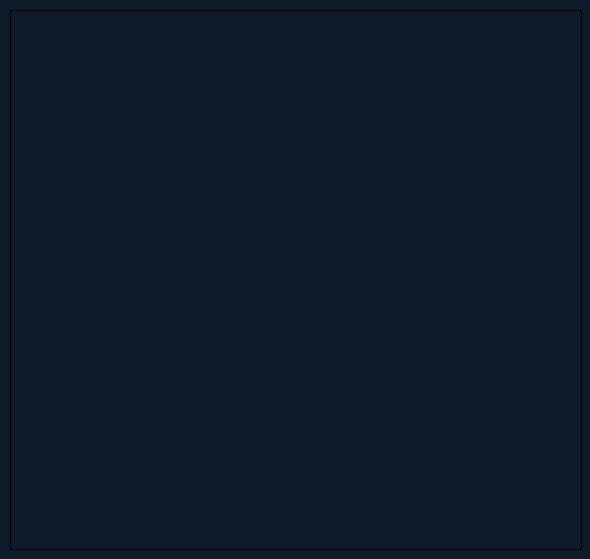

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr


# ─── Coordenadas de Juazeiro-BA ──────────────────────────────────────────────
JUAZEIRO_LON = -40.50
JUAZEIRO_LAT = -9.42


def plot_nordeste_temperatura(ds: xr.Dataset, time_index: int = 0) -> plt.Figure:
    """
    Plota a temperatura a 2 m (t2m) do Dataset GFS sobre o Nordeste do Brasil.

    Parâmetros
    ----------
    ds         : xr.Dataset  — Dataset com variável 't2m' e dims (time, latitude, longitude)
    time_index : int          — Índice no eixo time a ser exibido (0 = hora inicial)

    Retorna
    -------
    fig : matplotlib.figure.Figure
    """
    # ── Seleciona o time step ────────────────────────────────────────────────
    da = ds["t2m"].isel(time=time_index)
    timestamp = str(da.time.values)[:16].replace("T", " ") + " UTC"

    # ── Recorte espacial: Nordeste + margem ──────────────────────────────────
    lon_min, lon_max = -50.0, -32.0
    lat_min, lat_max = -18.0,  -1.0

    # GFS: longitude em 0-360 → converte limites
    gfs_lon_min = lon_min % 360   # 310.0
    gfs_lon_max = lon_max % 360   # 328.0

    # GFS: latitude decrescente (90 → -90) → slice(maior, menor)
    da_reg = da.sel(
        latitude=slice(lat_max, lat_min),
        longitude=slice(gfs_lon_min, gfs_lon_max),
    )

    # Converte longitudes de volta para -180/180 para o Cartopy
    lons = da_reg.longitude.values - 360
    lats = da_reg.latitude.values
    temp_C = da_reg.values - 273.15          # Kelvin → Celsius

    # ── Temperatura em Juazeiro-BA (ponto de grade mais próximo) ────────────
    da_jua = ds["t2m"].isel(time=time_index).sel(
        latitude=JUAZEIRO_LAT,
        longitude=JUAZEIRO_LON % 360,        # GFS usa 0-360
        method="nearest",
    )
    temp_jua = float(da_jua.values) - 273.15

    # ── Figura e projeção ───────────────────────────────────────────────────
    proj = ccrs.PlateCarree()
    fig, ax = plt.subplots(
        figsize=(9, 7),
        subplot_kw={"projection": proj},
        facecolor="#0d1b2a",
    )
    ax.set_facecolor("#0d1b2a")
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)

    # ── Colormap customizado para temperatura ───────────────────────────────
    cmap = plt.colormaps["RdYlBu_r"]
    vmin, vmax = 10, 45

    mesh = ax.pcolormesh(
        lons, lats, temp_C,
        cmap=cmap, vmin=vmin, vmax=vmax,
        transform=proj, shading="nearest",
        alpha=0.92,
    )

    # ── Feições cartográficas ────────────────────────────────────────────────
    ax.add_feature(cfeature.COASTLINE.with_scale("10m"),  linewidth=0.8, color="#e0e0e0")
    ax.add_feature(cfeature.BORDERS.with_scale("10m"),    linewidth=0.6, color="#aaaaaa")
    ax.add_feature(cfeature.STATES.with_scale("10m"),     linewidth=0.4, color="#888888")
    ax.add_feature(cfeature.OCEAN.with_scale("50m"),      facecolor="#122033")
    ax.add_feature(cfeature.RIVERS.with_scale("10m"),     linewidth=0.3, edgecolor="#4ab8f5", alpha=0.5)

    # ── Marcador de Juazeiro-BA ──────────────────────────────────────────────
    ax.plot(
        JUAZEIRO_LON, JUAZEIRO_LAT,
        marker="o", markersize=9,
        color="#ff4f4f", markeredgecolor="white", markeredgewidth=1.4,
        transform=proj, zorder=6,
    )
    ax.annotate(
        f"Juazeiro-BA\n{temp_jua:.1f} °C",
        xy=(JUAZEIRO_LON, JUAZEIRO_LAT),
        xytext=(JUAZEIRO_LON + 1.8, JUAZEIRO_LAT - 1.2),
        fontsize=9, fontweight="bold", color="white",
        transform=proj, zorder=7,
        bbox=dict(boxstyle="round,pad=0.35", fc="#ff4f4f", ec="white", lw=0.8, alpha=0.88),
        arrowprops=dict(arrowstyle="-", color="white", lw=0.8),
    )

    # ── Colorbar ─────────────────────────────────────────────────────────────
    cbar = plt.colorbar(mesh, ax=ax, orientation="vertical", pad=0.02, fraction=0.03)
    cbar.set_label("Temperatura (°C)", color="white", fontsize=10)
    cbar.ax.yaxis.set_tick_params(color="white", labelcolor="white")

    # ── Gridlines ────────────────────────────────────────────────────────────
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"color": "white", "fontsize": 8}
    gl.ylabel_style = {"color": "white", "fontsize": 8}

    # ── Títulos ───────────────────────────────────────────────────────────────
    run_info = f"GFS {ds.attrs.get('run_date','?')} {ds.attrs.get('run_cycle','?')}Z"
    ax.set_title(
        f"Temperatura a 2 m — Nordeste do Brasil\n{timestamp}  |  {run_info}",
        color="white", fontsize=11, pad=10,
    )

    fig.tight_layout()
    return fig


# ─── Exemplo de uso ──────────────────────────────────────────────────────────
if __name__ == "__main__":
    # Substitua pelo caminho real do seu arquivo NetCDF / Zarr
    # ds = xr.open_dataset("gfs_t2m.nc")

    # Demo com dados sintéticos (mesma estrutura do Dataset descrito)


    for t in [0, 6, 12, 24]:
        fig = plot_nordeste_temperatura(data._ds, time_index=t)
        fig.savefig(f"nordeste_t{t:03d}.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
        print(f"Salvo: nordeste_t{t:03d}.png  |  time_index={t}")
        plt.close(fig)

In [6]:
data['time']

<xarray.IndexVariable 'time' (time: 129)> Size: 1kB
array(['2026-04-06T00:00:00.000000000', '2026-04-06T03:00:00.000000000',
       '2026-04-06T06:00:00.000000000', '2026-04-06T09:00:00.000000000',
       '2026-04-06T12:00:00.000000000', '2026-04-06T15:00:00.000000000',
       '2026-04-06T18:00:00.000000000', '2026-04-06T21:00:00.000000000',
       '2026-04-07T00:00:00.000000000', '2026-04-07T03:00:00.000000000',
       '2026-04-07T06:00:00.000000000', '2026-04-07T09:00:00.000000000',
       '2026-04-07T12:00:00.000000000', '2026-04-07T15:00:00.000000000',
       '2026-04-07T18:00:00.000000000', '2026-04-07T21:00:00.000000000',
       '2026-04-08T00:00:00.000000000', '2026-04-08T03:00:00.000000000',
       '2026-04-08T06:00:00.000000000', '2026-04-08T09:00:00.000000000',
       '2026-04-08T12:00:00.000000000', '2026-04-08T15:00:00.000000000',
       '2026-04-08T18:00:00.000000000', '2026-04-08T21:00:00.000000000',
       '2026-04-09T00:00:00.000000000', '2026-04-09T03:00:00.000000000',
       '2026-04-09T06:00:00.000000000', '2026-04-09T09:00:00.000000000',
       '2026-04-09T12:00:00.000000000', '2026-04-09T15:00:00.000000000',
       '2026-04-09T18:00:00.000000000', '2026-04-09T21:00:00.000000000',
       '2026-04-10T00:00:00.000000000', '2026-04-10T03:00:00.000000000',
       '2026-04-10T06:00:00.000000000', '2026-04-10T09:00:00.000000000',
       '2026-04-10T12:00:00.000000000', '2026-04-10T15:00:00.000000000',
       '2026-04-10T18:00:00.000000000', '2026-04-10T21:00:00.000000000',
       '2026-04-11T00:00:00.000000000', '2026-04-11T03:00:00.000000000',
       '2026-04-11T06:00:00.000000000', '2026-04-11T09:00:00.000000000',
       '2026-04-11T12:00:00.000000000', '2026-04-11T15:00:00.000000000',
       '2026-04-11T18:00:00.000000000', '2026-04-11T21:00:00.000000000',
       '2026-04-12T00:00:00.000000000', '2026-04-12T03:00:00.000000000',
       '2026-04-12T06:00:00.000000000', '2026-04-12T09:00:00.000000000',
       '2026-04-12T12:00:00.000000000', '2026-04-12T15:00:00.000000000',
       '2026-04-12T18:00:00.000000000', '2026-04-12T21:00:00.000000000',
       '2026-04-13T00:00:00.000000000', '2026-04-13T03:00:00.000000000',
       '2026-04-13T06:00:00.000000000', '2026-04-13T09:00:00.000000000',
       '2026-04-13T12:00:00.000000000', '2026-04-13T15:00:00.000000000',
       '2026-04-13T18:00:00.000000000', '2026-04-13T21:00:00.000000000',
       '2026-04-14T00:00:00.000000000', '2026-04-14T03:00:00.000000000',
       '2026-04-14T06:00:00.000000000', '2026-04-14T09:00:00.000000000',
       '2026-04-14T12:00:00.000000000', '2026-04-14T15:00:00.000000000',
       '2026-04-14T18:00:00.000000000', '2026-04-14T21:00:00.000000000',
       '2026-04-15T00:00:00.000000000', '2026-04-15T03:00:00.000000000',
       '2026-04-15T06:00:00.000000000', '2026-04-15T09:00:00.000000000',
       '2026-04-15T12:00:00.000000000', '2026-04-15T15:00:00.000000000',
       '2026-04-15T18:00:00.000000000', '2026-04-15T21:00:00.000000000',
       '2026-04-16T00:00:00.000000000', '2026-04-16T03:00:00.000000000',
       '2026-04-16T06:00:00.000000000', '2026-04-16T09:00:00.000000000',
       '2026-04-16T12:00:00.000000000', '2026-04-16T15:00:00.000000000',
       '2026-04-16T18:00:00.000000000', '2026-04-16T21:00:00.000000000',
       '2026-04-17T00:00:00.000000000', '2026-04-17T03:00:00.000000000',
       '2026-04-17T06:00:00.000000000', '2026-04-17T09:00:00.000000000',
       '2026-04-17T12:00:00.000000000', '2026-04-17T15:00:00.000000000',
       '2026-04-17T18:00:00.000000000', '2026-04-17T21:00:00.000000000',
       '2026-04-18T00:00:00.000000000', '2026-04-18T03:00:00.000000000',
       '2026-04-18T06:00:00.000000000', '2026-04-18T09:00:00.000000000',
       '2026-04-18T12:00:00.000000000', '2026-04-18T15:00:00.000000000',
       '2026-04-18T18:00:00.000000000', '2026-04-18T21:00:00.000000000',
       '2026-04-19T00:00:00.000000000', '2026-04-19T03:00:00.000000000',
       '2026-04-19T06:00:00.000000000', '2026-04-19T09:00:00.000000000',
      

In [7]:
data['t2m']

<xarray.Variable (time: 129, latitude: 721, longitude: 1440)> Size: 1GB
array([[[-20.84770813, -20.84770813, -20.84770813, ..., -20.84770813,
         -20.84770813, -20.84770813],
        [-20.84770813, -20.84770813, -20.84770813, ..., -20.84770813,
         -20.84770813, -20.84770813],
        [-24.24770203, -24.24770203, -24.14771118, ..., -24.24770203,
         -24.24770203, -24.24770203],
        ...,
        [-49.64771118, -49.64771118, -49.64771118, ..., -49.64771118,
         -49.64771118, -49.64771118],
        [-49.44769897, -49.44769897, -49.44769897, ..., -49.44769897,
         -49.44769897, -49.44769897],
        [-49.44769897, -49.44769897, -49.44769897, ..., -49.44769897,
         -49.44769897, -49.44769897]],

       [[-22.14996948, -22.14996948, -22.14996948, ..., -22.14996948,
         -22.14996948, -22.14996948],
        [-20.44997253, -20.44997253, -20.44997253, ..., -20.44997253,
         -20.44997253, -20.44997253],
        [-24.34998169, -24.34998169, -24.34998169, ..., -24.44997253,
         -24.44997253, -24.34998169],
...
        [-48.09255066, -48.09255066, -48.09255066, ..., -48.19255676,
         -48.19255676, -48.09255066],
        [-50.19255676, -50.19255676, -50.19255676, ..., -50.19255676,
         -50.19255676, -50.19255676],
        [-51.89255371, -51.89255371, -51.89255371, ..., -51.89255371,
         -51.89255371, -51.89255371]],

       [[-20.95000305, -20.95000305, -20.95000305, ..., -20.95000305,
         -20.95000305, -20.95000305],
        [-20.2500061 , -20.2500061 , -20.2500061 , ..., -20.2500061 ,
         -20.2500061 , -20.2500061 ],
        [-20.15      , -20.15      , -20.15      , ..., -20.15      ,
         -20.15      , -20.15      ],
        ...,
        [-50.45000305, -50.45000305, -50.45000305, ..., -50.5499939 ,
         -50.5499939 , -50.45000305],
        [-52.15      , -52.15      , -52.15      , ..., -52.15      ,
         -52.15      , -52.15      ],
        [-53.65      , -53.65      , -53.65      , ..., -53.65      ,
         -53.65      , -53.65      ]]], shape=(129, 721, 1440))
Attributes:
    long_name:  2 metre temperature
    units:      C
    gfs_run:    20260406 00Z

In [8]:
jua_data = data.get_data_from_place('juazeiro BA')

In [10]:
jua_data

<_DatasetView>
<xarray.Dataset> Size: 3kB
Dimensions:        (time: 129)
Coordinates:
  * time           (time) datetime64[ns] 1kB 2026-04-04 ... 2026-04-20
    latitude       float64 8B -9.5
    longitude      float64 8B -40.5
    forecast_hour  (time) int64 1kB 0 3 6 9 12 15 18 ... 369 372 375 378 381 384
Data variables:
    t2m            (time) float64 1kB 26.58 24.2 22.54 ... 32.71 28.41 26.8
Attributes:
    title:        GFS 0.25° — 2 metre temperature
    institution:  NCEP/NOAA
    source:       GFS model output (NOMADS)
    run_date:     20260404
    run_cycle:    00
    created:      2026-04-05T02:50:29.754561Z

In [12]:
jua_data['time']

<xarray.IndexVariable 'time' (time: 129)> Size: 1kB
array(['2026-04-04T00:00:00.000000000', '2026-04-04T03:00:00.000000000',
       '2026-04-04T06:00:00.000000000', '2026-04-04T09:00:00.000000000',
       '2026-04-04T12:00:00.000000000', '2026-04-04T15:00:00.000000000',
       '2026-04-04T18:00:00.000000000', '2026-04-04T21:00:00.000000000',
       '2026-04-05T00:00:00.000000000', '2026-04-05T03:00:00.000000000',
       '2026-04-05T06:00:00.000000000', '2026-04-05T09:00:00.000000000',
       '2026-04-05T12:00:00.000000000', '2026-04-05T15:00:00.000000000',
       '2026-04-05T18:00:00.000000000', '2026-04-05T21:00:00.000000000',
       '2026-04-06T00:00:00.000000000', '2026-04-06T03:00:00.000000000',
       '2026-04-06T06:00:00.000000000', '2026-04-06T09:00:00.000000000',
       '2026-04-06T12:00:00.000000000', '2026-04-06T15:00:00.000000000',
       '2026-04-06T18:00:00.000000000', '2026-04-06T21:00:00.000000000',
       '2026-04-07T00:00:00.000000000', '2026-04-07T03:00:00.000000000',
       '2026-04-07T06:00:00.000000000', '2026-04-07T09:00:00.000000000',
       '2026-04-07T12:00:00.000000000', '2026-04-07T15:00:00.000000000',
       '2026-04-07T18:00:00.000000000', '2026-04-07T21:00:00.000000000',
       '2026-04-08T00:00:00.000000000', '2026-04-08T03:00:00.000000000',
       '2026-04-08T06:00:00.000000000', '2026-04-08T09:00:00.000000000',
       '2026-04-08T12:00:00.000000000', '2026-04-08T15:00:00.000000000',
       '2026-04-08T18:00:00.000000000', '2026-04-08T21:00:00.000000000',
       '2026-04-09T00:00:00.000000000', '2026-04-09T03:00:00.000000000',
       '2026-04-09T06:00:00.000000000', '2026-04-09T09:00:00.000000000',
       '2026-04-09T12:00:00.000000000', '2026-04-09T15:00:00.000000000',
       '2026-04-09T18:00:00.000000000', '2026-04-09T21:00:00.000000000',
       '2026-04-10T00:00:00.000000000', '2026-04-10T03:00:00.000000000',
       '2026-04-10T06:00:00.000000000', '2026-04-10T09:00:00.000000000',
       '2026-04-10T12:00:00.000000000', '2026-04-10T15:00:00.000000000',
       '2026-04-10T18:00:00.000000000', '2026-04-10T21:00:00.000000000',
       '2026-04-11T00:00:00.000000000', '2026-04-11T03:00:00.000000000',
       '2026-04-11T06:00:00.000000000', '2026-04-11T09:00:00.000000000',
       '2026-04-11T12:00:00.000000000', '2026-04-11T15:00:00.000000000',
       '2026-04-11T18:00:00.000000000', '2026-04-11T21:00:00.000000000',
       '2026-04-12T00:00:00.000000000', '2026-04-12T03:00:00.000000000',
       '2026-04-12T06:00:00.000000000', '2026-04-12T09:00:00.000000000',
       '2026-04-12T12:00:00.000000000', '2026-04-12T15:00:00.000000000',
       '2026-04-12T18:00:00.000000000', '2026-04-12T21:00:00.000000000',
       '2026-04-13T00:00:00.000000000', '2026-04-13T03:00:00.000000000',
       '2026-04-13T06:00:00.000000000', '2026-04-13T09:00:00.000000000',
       '2026-04-13T12:00:00.000000000', '2026-04-13T15:00:00.000000000',
       '2026-04-13T18:00:00.000000000', '2026-04-13T21:00:00.000000000',
       '2026-04-14T00:00:00.000000000', '2026-04-14T03:00:00.000000000',
       '2026-04-14T06:00:00.000000000', '2026-04-14T09:00:00.000000000',
       '2026-04-14T12:00:00.000000000', '2026-04-14T15:00:00.000000000',
       '2026-04-14T18:00:00.000000000', '2026-04-14T21:00:00.000000000',
       '2026-04-15T00:00:00.000000000', '2026-04-15T03:00:00.000000000',
       '2026-04-15T06:00:00.000000000', '2026-04-15T09:00:00.000000000',
       '2026-04-15T12:00:00.000000000', '2026-04-15T15:00:00.000000000',
       '2026-04-15T18:00:00.000000000', '2026-04-15T21:00:00.000000000',
       '2026-04-16T00:00:00.000000000', '2026-04-16T03:00:00.000000000',
       '2026-04-16T06:00:00.000000000', '2026-04-16T09:00:00.000000000',
       '2026-04-16T12:00:00.000000000', '2026-04-16T15:00:00.000000000',
       '2026-04-16T18:00:00.000000000', '2026-04-16T21:00:00.000000000',
       '2026-04-17T00:00:00.000000000', '2026-04-17T03:00:00.000000000',
       '2026-04-17T06:00:00.000000000', '2026-04-17T09:00:00.000000000',
      

In [14]:
"""
Plot climático de Juazeiro - BA
Geração de imagem para publicação no Instagram @reinanbr
"""

import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.lines
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.collections import LineCollection
import matplotlib.ticker as mticker
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

# ── Tenta importar a lib; se não, gera dados sintéticos ───────────────────
try:
    from noawclg.main import get_noaa_data
    print("⏳ Baixando dados GFS para Juazeiro-BA…")
    noaa = get_noaa_data(key="t2m",date=20260404)
    view = noaa.get_data_from_place("Juazeiro, Bahia, Brazil")
    ds   = view.dataset
    time_vals = ds["time"].values
    t2m_vals  = ds["t2m"].values
    lat_val   = float(ds["latitude"].values)
    lon_val   = float(ds["longitude"].values)
    DATA_SOURCE = "GFS 0.25° / NOAA · NOMADS"
except Exception as e:
    print(f"⚠️  Usando dados sintéticos ({e})")
    n = 129
    time_vals = np.array([
        np.datetime64("2026-04-04T00:00") + np.timedelta64(3 * i, "h")
        for i in range(n)
    ])
    np.random.seed(42)
    hours = np.arange(n) * 3
    base  = 29 + 6 * np.sin((hours % 24 - 6) * np.pi / 12)
    trend = -0.005 * hours
    noise = np.random.normal(0, 0.4, n)
    t2m_vals = base + trend + noise
    lat_val, lon_val = -9.4168, -40.5019
    DATA_SOURCE = "Dados sintéticos (exemplo)"


def to_dt(v):
    ts = (v - np.datetime64("1970-01-01T00:00")) / np.timedelta64(1, "s")
    return datetime.utcfromtimestamp(float(ts))


dts    = [to_dt(v) for v in time_vals]
t_days = np.array([(d - dts[0]).total_seconds() / 86400 for d in dts])
t_c    = t2m_vals.astype(float)

t_max   = float(np.max(t_c))
t_min   = float(np.min(t_c))
t_mean  = float(np.mean(t_c))
t_range = t_max - t_min
idx_max = int(np.argmax(t_c))
idx_min = int(np.argmin(t_c))

# ── Paleta ────────────────────────────────────────────────────────────────
BG       = "#0D0D0D"
CARD     = "#111111"
ACCENT1  = "#FF6B2B"
ACCENT2  = "#FFB347"
ACCENT3  = "#E03A2F"
COOL     = "#4FC3C3"
GRID_C   = "#1E1E1E"
TEXT_PRI = "#F5F0E8"
TEXT_SEC = "#888880"
TEXT_DIM = "#444440"

cmap_line = LinearSegmentedColormap.from_list(
    "sertao", ["#4FC3C3", "#FFB347", "#FF6B2B", "#E03A2F"], N=256
)

# ── Figura ────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 16), dpi=130)
fig.patch.set_facecolor(BG)

ax = fig.add_axes([0.08, 0.28, 0.88, 0.50])
ax.set_facecolor(CARD)

# ── Cabeçalho ─────────────────────────────────────────────────────────────
fig.text(0.08, 0.944,
         "PREVISÃO DE TEMPERATURA · GFS 0.25°",
         color=TEXT_SEC, fontsize=9, fontfamily="monospace",
         fontweight="bold", va="bottom")

fig.text(0.08, 0.912,
         "Juazeiro — BA",
         color=TEXT_PRI, fontsize=32, fontweight="black", va="top",
         path_effects=[pe.withStroke(linewidth=5, foreground=BG)])

fig.text(0.08, 0.858,
         (f"lat {lat_val:.2f}°  ·  lon {lon_val:.2f}°  ·  "
          f"{dts[0].strftime('%d %b %Y')} → {dts[-1].strftime('%d %b %Y')}"),
         color=TEXT_SEC, fontsize=8.5, fontfamily="monospace", va="top")

fig.add_artist(matplotlib.lines.Line2D(
    [0.08, 0.62], [0.850, 0.850],
    transform=fig.transFigure, color=ACCENT1, linewidth=2.5
))

# ── Gráfico ───────────────────────────────────────────────────────────────
y_lo = t_min - 2.5
y_hi = t_max + 2.5
ax.set_xlim(t_days[0], t_days[-1])
ax.set_ylim(y_lo, y_hi)

for y in np.arange(np.floor(t_min - 2), np.ceil(t_max + 3), 2):
    ax.axhline(y, color=GRID_C, linewidth=0.6, zorder=0)

ax.axhspan(18, 24, color=COOL, alpha=0.07, zorder=1)

# gradiente preenchido
t_i   = np.linspace(t_days[0], t_days[-1], 600)
c_i   = np.interp(t_i, t_days, t_c)
nv    = (c_i - t_min) / max(t_max - t_min, 0.01)
for k in range(len(t_i) - 1):
    ax.fill_between(t_i[k:k+2], y_lo, c_i[k:k+2],
                    color=cmap_line(nv[k]), alpha=0.13,
                    linewidth=0, zorder=2)

# linha colorida
pts  = np.array([t_days, t_c]).T.reshape(-1, 1, 2)
segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
lc   = LineCollection(segs, cmap=cmap_line,
                       norm=plt.Normalize(t_min, t_max),
                       linewidth=2.6, zorder=5, capstyle="round")
lc.set_array((t_c[:-1] + t_c[1:]) / 2)
ax.add_collection(lc)

# marcador máximo
def _annot_side(idx):
    return 1.2 if t_days[idx] < t_days[-1] * 0.75 else -3.8

ax.scatter(t_days[idx_max], t_c[idx_max],
           s=100, color=ACCENT3, zorder=10,
           edgecolors=TEXT_PRI, linewidths=1.1)
ax.annotate(
    f" MÁX  {t_c[idx_max]:.1f}°C",
    xy=(t_days[idx_max], t_c[idx_max]),
    xytext=(t_days[idx_max] + _annot_side(idx_max), t_c[idx_max] + 1.2),
    color=ACCENT3, fontsize=8.5, fontweight="bold",
    fontfamily="monospace", zorder=11,
    arrowprops=dict(arrowstyle="-", color=ACCENT3, lw=0.8),
)

# marcador mínimo
ax.scatter(t_days[idx_min], t_c[idx_min],
           s=100, color=COOL, zorder=10,
           edgecolors=TEXT_PRI, linewidths=1.1)
ax.annotate(
    f" MÍN  {t_c[idx_min]:.1f}°C",
    xy=(t_days[idx_min], t_c[idx_min]),
    xytext=(t_days[idx_min] + _annot_side(idx_min), t_c[idx_min] - 2.2),
    color=COOL, fontsize=8.5, fontweight="bold",
    fontfamily="monospace", zorder=11,
    arrowprops=dict(arrowstyle="-", color=COOL, lw=0.8),
)

# eixos
unique_days = sorted(set(d.date() for d in dts))
tick_dts    = [dts[next(i for i, dd in enumerate(dts) if dd.date() == ud)]
               for ud in unique_days[::2]]
tick_x      = [(d - dts[0]).total_seconds() / 86400 for d in tick_dts]
tick_lbl    = [d.strftime("%d/%m") for d in tick_dts]

ax.set_xticks(tick_x)
ax.set_xticklabels(tick_lbl, color=TEXT_SEC, fontsize=8.5,
                   fontfamily="monospace")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f°"))
ax.tick_params(axis="y", colors=TEXT_SEC, labelsize=9)
ax.tick_params(axis="x", colors=TEXT_DIM, length=3)
for sp in ax.spines.values():
    sp.set_edgecolor(GRID_C)

ax.set_ylabel("Temperatura  (°C)", color=TEXT_SEC, fontsize=9,
              fontfamily="monospace", labelpad=10)

ax.legend(
    handles=[mpatches.Patch(color=COOL, alpha=0.35,
                             label="Zona de conforto  18–24 °C")],
    loc="upper right", framealpha=0,
    labelcolor=TEXT_SEC, fontsize=8,
)

# ── Separador ─────────────────────────────────────────────────────────────
fig.add_artist(matplotlib.lines.Line2D(
    [0.08, 0.96], [0.265, 0.265],
    transform=fig.transFigure, color=GRID_C, linewidth=1,
))

# ── Cards de estatísticas ─────────────────────────────────────────────────
stats = [
    ("MÁXIMA",    f"{t_max:.1f}°C",    ACCENT3),
    ("MÍNIMA",    f"{t_min:.1f}°C",    COOL),
    ("MÉDIA",     f"{t_mean:.1f}°C",   ACCENT2),
    ("AMPLITUDE", f"{t_range:.1f}°C",  TEXT_PRI),
]
xs_cards = [0.08, 0.30, 0.54, 0.76]
for (label, value, color), xc in zip(stats, xs_cards):
    fig.text(xc, 0.246, label,
             color=TEXT_SEC, fontsize=7.5, fontfamily="monospace",
             fontweight="bold", va="top")
    fig.text(xc, 0.218, value,
             color=color, fontsize=22, fontweight="black", va="top")
    fig.add_artist(matplotlib.lines.Line2D(
        [xc, xc + 0.17], [0.165, 0.165],
        transform=fig.transFigure, color=color, linewidth=2.2,
    ))

# ── Rodapé ────────────────────────────────────────────────────────────────
fig.add_artist(matplotlib.lines.Line2D(
    [0.08, 0.96], [0.075, 0.075],
    transform=fig.transFigure, color=GRID_C, linewidth=1,
))
run_str = datetime.utcnow().strftime("%Y-%m-%dT%H:%MZ")
fig.text(0.08, 0.060,
         f"Fonte: {DATA_SOURCE}   ·   Gerado: {run_str}",
         color=TEXT_DIM, fontsize=7.5, fontfamily="monospace", va="top")
fig.text(0.96, 0.060,
         "@reinanbr",
         color=ACCENT1, fontsize=13, fontweight="black",
         fontfamily="monospace", va="top", ha="right",
         path_effects=[pe.withStroke(linewidth=4, foreground=BG)])

# ── Salvar ────────────────────────────────────────────────────────────────
OUTPUT = "juazeiro_ba_clima.png"
fig.savefig(OUTPUT, dpi=130, bbox_inches="tight",
            facecolor=BG, edgecolor="none")
print(f"✅  Imagem salva em: {OUTPUT}")
plt.close(fig)

⏳ Baixando dados GFS para Juazeiro-BA…
⚠️  Usando dados sintéticos (strptime() argument 1 must be str, not int)
✅  Imagem salva em: juazeiro_ba_clima.png


In [6]:
"""
Plots climáticos de Juazeiro - BA
4 variáveis: pressão, precipitação, humidade relativa, água em nuvens
Publicação Instagram @reinanbr
"""

import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.lines
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.collections import LineCollection
import matplotlib.ticker as mticker
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# DADOS
# ─────────────────────────────────────────────────────────────────────────────
def to_dt(v):
    ts = (v - np.datetime64("1970-01-01T00:00")) / np.timedelta64(1, "s")
    return datetime.utcfromtimestamp(float(ts))


VARS_NEEDED = ["prmsl", "prate", "r2", "cwat"]

try:
    from noawclg.main import get_noaa_data
    print("⏳ Baixando dados GFS para Juazeiro-BA…")
    raw = {}
    time_vals = lat_val = lon_val = None
    noaa = get_noaa_data(keys=VARS_NEEDED,date='20260404')
    view = noaa.get_data_from_place("Juazeiro, Bahia, Brazil")
    ds   = view.dataset
    for key in VARS_NEEDED:
        
        if time_vals is None:
            time_vals = ds["time"].values
            lat_val   = float(ds["latitude"].values)
            lon_val   = float(ds["longitude"].values)
        raw[key] = ds[key].values.astype(float)
    DATA_SOURCE = "GFS 0.25° / NOAA · NOMADS"
except Exception as e:
    print(f"⚠️  Usando dados sintéticos ({e})")
    n = 129
    time_vals = np.array([
        np.datetime64("2026-04-04T00:00") + np.timedelta64(3 * i, "h")
        for i in range(n)
    ])
    np.random.seed(7)
    hours = np.arange(n) * 3
    # prmsl: pressão ao nível do mar  ~1010 hPa com ciclo lento
    raw = {
        "prmsl": 1010 + 3 * np.sin(hours / 36 * np.pi) + np.random.normal(0, 0.4, n),
        # prate: taxa de precipitação kg/m²/s (geralmente muito pequena no sertão)
        "prate": np.clip(
            np.where(hours % 48 < 6, np.random.exponential(1e-4, n), 0)
            + np.random.exponential(5e-5, n) * 0.2,
            0, None
        ),
        # r2: humidade relativa 2m  30–80%
        "r2": np.clip(
            55 + 25 * np.sin((hours % 24 - 4) * np.pi / 12)
            + np.random.normal(0, 3, n),
            15, 98
        ),
        # cwat: água em nuvens kg/m²
        "cwat": np.clip(
            0.15 + 0.25 * np.abs(np.sin(hours / 48 * np.pi))
            + np.random.exponential(0.04, n),
            0, None
        ),
    }
    lat_val, lon_val = -9.4168, -40.5019
    DATA_SOURCE = "Dados sintéticos (exemplo)"

# prate → mm/h para exibição (×3600)
prate_mmh = raw["prate"] * 3600.0

dts    = [to_dt(v) for v in time_vals]
t_days = np.array([(d - dts[0]).total_seconds() / 86400 for d in dts])

# ─────────────────────────────────────────────────────────────────────────────
# TEMA
# ─────────────────────────────────────────────────────────────────────────────
BG       = "#0D0D0D"
CARD     = "#111111"
GRID_C   = "#1A1A1A"
TEXT_PRI = "#F5F0E8"
TEXT_SEC = "#888880"
TEXT_DIM = "#3E3E3A"
HANDLE   = "#FF6B2B"   # @reinanbr accent

# paletas por variável
CMAPS = {
    "prmsl": LinearSegmentedColormap.from_list("pres",  ["#334FBF", "#7EB3FF", "#E8F4FD"], N=256),
    "prate": LinearSegmentedColormap.from_list("rain",  ["#0D2B45", "#1A85C2", "#53D8FB", "#AAFFF0"], N=256),
    "r2":    LinearSegmentedColormap.from_list("hum",   ["#B45309", "#F59E0B", "#86EFAC", "#22D3EE"], N=256),
    "cwat":  LinearSegmentedColormap.from_list("cloud", ["#1C2333", "#475569", "#94A3B8", "#E2E8F0"], N=256),
}
ACCENT = {
    "prmsl": "#7EB3FF",
    "prate": "#53D8FB",
    "r2":    "#86EFAC",
    "cwat":  "#94A3B8",
}
ACCENT_HI = {
    "prmsl": "#E8F4FD",
    "prate": "#AAFFF0",
    "r2":    "#22D3EE",
    "cwat":  "#E2E8F0",
}

# configurações por variável
CFGS = {
    "prmsl": dict(
        label   = "PRESSÃO ATMOSFÉRICA",
        title   = "Pressão Atm.",
        unit    = "hPa",
        ylabel  = "Pressão  (hPa)",
        fmt     = "%.0f",
        values  = raw["prmsl"],
        stat_lo = "MÍN",
        stat_hi = "MÁX",
        refband = None,
    ),
    "prate": dict(
        label   = "PRECIPITAÇÃO",
        title   = "Precipitação",
        unit    = "mm/h",
        ylabel  = "Taxa  (mm h⁻¹)",
        fmt     = "%.3f",
        values  = prate_mmh,
        stat_lo = "MÍN",
        stat_hi = "MÁX",
        refband = None,
        bar_plot = True,       # barras em vez de linha
    ),
    "r2": dict(
        label   = "HUMIDADE RELATIVA",
        title   = "Humidade Relativa",
        unit    = "%",
        ylabel  = "Humidade  (%)",
        fmt     = "%.0f",
        values  = raw["r2"],
        stat_lo = "MÍN",
        stat_hi = "MÁX",
        refband = (60, 80),    # faixa confortável
    ),
    "cwat": dict(
        label   = "ÁGUA EM NUVENS",
        title   = "Água em Nuvens",
        unit    = "kg m⁻²",
        ylabel  = "Água em nuvens  (kg m⁻²)",
        fmt     = "%.3f",
        values  = raw["cwat"],
        stat_lo = "MÍN",
        stat_hi = "MÁX",
        refband = None,
    ),
}


# ─────────────────────────────────────────────────────────────────────────────
# FUNÇÕES AUXILIARES
# ─────────────────────────────────────────────────────────────────────────────
def _tick_dates(dts, t_days, step=2):
    unique = sorted(set(d.date() for d in dts))
    tdts   = [dts[next(i for i, dd in enumerate(dts) if dd.date() == ud)]
              for ud in unique[::step]]
    tx     = [(d - dts[0]).total_seconds() / 86400 for d in tdts]
    tl     = [d.strftime("%d/%m") for d in tdts]
    return tx, tl


def _annot_side(idx, t_days):
    return 1.0 if t_days[idx] < t_days[-1] * 0.75 else -3.5


def _header(fig, label, title, unit, lat_val, lon_val, dts, accent, run_str, DATA_SOURCE):
    fig.text(0.08, 0.950, label + "  ·  GFS 0.25°",
             color=TEXT_SEC, fontsize=8.5, fontfamily="monospace",
             fontweight="bold", va="bottom")
    fig.text(0.08, 0.918,
             f"Juazeiro — BA  ·  {title}",
             color=TEXT_PRI, fontsize=28, fontweight="black", va="top",
             path_effects=[pe.withStroke(linewidth=5, foreground=BG)])
    fig.text(0.08, 0.865,
             f"lat {lat_val:.2f}°  ·  lon {lon_val:.2f}°  ·  "
             f"{dts[0].strftime('%d %b %Y')} → {dts[-1].strftime('%d %b %Y')}",
             color=TEXT_SEC, fontsize=8, fontfamily="monospace", va="top")
    fig.add_artist(matplotlib.lines.Line2D(
        [0.08, 0.65], [0.858, 0.858],
        transform=fig.transFigure, color=accent, linewidth=2.2
    ))


def _footer(fig, DATA_SOURCE, run_str):
    fig.add_artist(matplotlib.lines.Line2D(
        [0.08, 0.96], [0.078, 0.078],
        transform=fig.transFigure, color=GRID_C, linewidth=1,
    ))
    fig.text(0.08, 0.063,
             f"Fonte: {DATA_SOURCE}   ·   Gerado: {run_str}",
             color=TEXT_DIM, fontsize=7.5, fontfamily="monospace", va="top")
    fig.text(0.96, 0.063,
             "@reinanbr",
             color=HANDLE, fontsize=13, fontweight="black",
             fontfamily="monospace", va="top", ha="right",
             path_effects=[pe.withStroke(linewidth=4, foreground=BG)])


def _stats_cards(fig, vals, unit, accent, accent_hi):
    v_max  = float(np.max(vals))
    v_min  = float(np.min(vals))
    v_mean = float(np.mean(vals))
    v_std  = float(np.std(vals))

    stats = [
        ("MÁXIMA",  f"{v_max:.2g} {unit}",  accent_hi),
        ("MÍNIMA",  f"{v_min:.2g} {unit}",  accent),
        ("MÉDIA",   f"{v_mean:.2g} {unit}", "#F5F0E8"),
        ("DESVIO",  f"{v_std:.2g} {unit}",  TEXT_SEC),
    ]
    fig.add_artist(matplotlib.lines.Line2D(
        [0.08, 0.96], [0.270, 0.270],
        transform=fig.transFigure, color=GRID_C, linewidth=1,
    ))
    xs = [0.08, 0.30, 0.54, 0.76]
    for (lbl, val, col), x in zip(stats, xs):
        fig.text(x, 0.252, lbl,
                 color=TEXT_SEC, fontsize=7.5, fontfamily="monospace",
                 fontweight="bold", va="top")
        fig.text(x, 0.224, val,
                 color=col, fontsize=18, fontweight="black", va="top")
        fig.add_artist(matplotlib.lines.Line2D(
            [x, x + 0.17], [0.170, 0.170],
            transform=fig.transFigure, color=col, linewidth=2.0,
        ))


def _make_ax(fig):
    ax = fig.add_axes([0.08, 0.29, 0.88, 0.50])
    ax.set_facecolor(CARD)
    return ax


def _style_ax(ax, t_days, tick_x, tick_lbl, ylabel, fmt):
    ax.set_xlim(t_days[0], t_days[-1])
    ax.set_xticks(tick_x)
    ax.set_xticklabels(tick_lbl, color=TEXT_SEC, fontsize=8,
                        fontfamily="monospace")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter(fmt))
    ax.tick_params(axis="y", colors=TEXT_SEC, labelsize=8.5)
    ax.tick_params(axis="x", colors=TEXT_DIM, length=3)
    for sp in ax.spines.values():
        sp.set_edgecolor(GRID_C)
    ax.set_ylabel(ylabel, color=TEXT_SEC, fontsize=8.5,
                  fontfamily="monospace", labelpad=10)


def _grid_lines(ax, vals):
    lo = float(np.min(vals))
    hi = float(np.max(vals))
    span = hi - lo
    step = max(span / 6, 1e-9)
    mag  = 10 ** np.floor(np.log10(step))
    step = round(step / mag) * mag
    for y in np.arange(np.floor(lo / step) * step,
                        np.ceil(hi  / step) * step + step, step):
        ax.axhline(y, color=GRID_C, linewidth=0.6, zorder=0)


def _colored_line(ax, t_days, vals, cmap):
    lo, hi = float(np.min(vals)), float(np.max(vals))
    pts  = np.array([t_days, vals]).T.reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    lc   = LineCollection(segs, cmap=cmap,
                           norm=plt.Normalize(lo, hi),
                           linewidth=2.5, zorder=5, capstyle="round")
    lc.set_array((vals[:-1] + vals[1:]) / 2)
    ax.add_collection(lc)
    # área preenchida
    t_i = np.linspace(t_days[0], t_days[-1], 600)
    c_i = np.interp(t_i, t_days, vals)
    nv  = (c_i - lo) / max(hi - lo, 1e-9)
    for k in range(len(t_i) - 1):
        ax.fill_between(t_i[k:k+2], lo - (hi-lo)*0.05, c_i[k:k+2],
                        color=cmap(nv[k]), alpha=0.12,
                        linewidth=0, zorder=2)


def _mark_extremes(ax, t_days, vals, accent, accent_hi):
    lo, hi = float(np.min(vals)), float(np.max(vals))
    span   = hi - lo
    i_hi   = int(np.argmax(vals))
    i_lo   = int(np.argmin(vals))

    def _side(idx): return 1.0 if t_days[idx] < t_days[-1]*0.75 else -3.5

    ax.scatter(t_days[i_hi], vals[i_hi], s=90, color=accent_hi,
               zorder=10, edgecolors=TEXT_PRI, linewidths=1.0)
    ax.annotate(f" MÁX  {vals[i_hi]:.3g}",
                xy=(t_days[i_hi], vals[i_hi]),
                xytext=(t_days[i_hi] + _side(i_hi), vals[i_hi] + span*0.08),
                color=accent_hi, fontsize=8, fontweight="bold",
                fontfamily="monospace", zorder=11,
                arrowprops=dict(arrowstyle="-", color=accent_hi, lw=0.7))

    ax.scatter(t_days[i_lo], vals[i_lo], s=90, color=accent,
               zorder=10, edgecolors=TEXT_PRI, linewidths=1.0)
    ax.annotate(f" MÍN  {vals[i_lo]:.3g}",
                xy=(t_days[i_lo], vals[i_lo]),
                xytext=(t_days[i_lo] + _side(i_lo), vals[i_lo] - span*0.12),
                color=accent, fontsize=8, fontweight="bold",
                fontfamily="monospace", zorder=11,
                arrowprops=dict(arrowstyle="-", color=accent, lw=0.7))


# ─────────────────────────────────────────────────────────────────────────────
# GERAÇÃO DOS 4 PLOTS
# ─────────────────────────────────────────────────────────────────────────────
run_str  = datetime.utcnow().strftime("%Y-%m-%dT%H:%MZ")
tick_x, tick_lbl = _tick_dates(dts, t_days, step=2)
outputs  = []

for key, cfg in CFGS.items():
    vals    = cfg["values"]
    cmap    = CMAPS[key]
    accent  = ACCENT[key]
    acc_hi  = ACCENT_HI[key]
    bar_plot = cfg.get("bar_plot", False)

    fig = plt.figure(figsize=(13, 16), dpi=130)
    fig.patch.set_facecolor(BG)

    ax = _make_ax(fig)

    # ── header ──
    _header(fig, cfg["label"], cfg["title"], cfg["unit"],
            lat_val, lon_val, dts, accent, run_str, DATA_SOURCE)

    # ── plot ──
    lo = float(np.min(vals))
    hi = float(np.max(vals))
    ax.set_ylim(lo - (hi-lo)*0.12, hi + (hi-lo)*0.18)
    _grid_lines(ax, vals)

    if cfg.get("refband"):
        ax.axhspan(*cfg["refband"], color=accent, alpha=0.07, zorder=1)

    if bar_plot:
        # barras coloridas por magnitude
        norm_v = (vals - lo) / max(hi - lo, 1e-9)
        colors = [cmap(v) for v in norm_v]
        bar_w  = (t_days[1] - t_days[0]) * 0.85
        ax.bar(t_days, vals, width=bar_w, color=colors,
               alpha=0.85, zorder=4, linewidth=0)
        # linha de média
        mean_v = float(np.mean(vals))
        ax.axhline(mean_v, color=accent, linewidth=1.2, linestyle="--",
                   alpha=0.6, zorder=6, label=f"Média  {mean_v:.3g} mm/h")
        ax.legend(loc="upper right", framealpha=0,
                  labelcolor=TEXT_SEC, fontsize=8)
    else:
        _colored_line(ax, t_days, vals, cmap)
        _mark_extremes(ax, t_days, vals, accent, acc_hi)

    _style_ax(ax, t_days, tick_x, tick_lbl, cfg["ylabel"], cfg["fmt"])

    # ── cards ──
    _stats_cards(fig, vals, cfg["unit"], accent, acc_hi)

    # ── rodapé ──
    _footer(fig, DATA_SOURCE, run_str)

    fname = f"juazeiro_ba_{key}.png"
    fig.savefig(fname, dpi=130, bbox_inches="tight",
                facecolor=BG, edgecolor="none")
    plt.close(fig)
    outputs.append(fname)
    print(f"✅  {fname}")

print("\nTodos os plots gerados:", outputs)

⏳ Baixando dados GFS para Juazeiro-BA…
⚠️  Usando dados sintéticos ('GFSDatasetManager' object has no attribute 'build_multi_variable_dataset')
✅  juazeiro_ba_prmsl.png
✅  juazeiro_ba_prate.png
✅  juazeiro_ba_r2.png
✅  juazeiro_ba_cwat.png

Todos os plots gerados: ['juazeiro_ba_prmsl.png', 'juazeiro_ba_prate.png', 'juazeiro_ba_r2.png', 'juazeiro_ba_cwat.png']


In [7]:
"""
Plots climáticos de Juazeiro - BA
5 variáveis: pressão, precipitação, humidade relativa, água em nuvens, temperatura
Opções de período: 1 dia (24h) ou 1 semana (7 dias)
Publicação Instagram @reinanbr
"""

import argparse
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.lines
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.collections import LineCollection
import matplotlib.ticker as mticker
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# ARGUMENTOS DE LINHA DE COMANDO
# ─────────────────────────────────────────────────────────────────────────────
parser = argparse.ArgumentParser(description="Plots climáticos Juazeiro-BA")
parser.add_argument(
    "--periodo",
    choices=["1dia", "1semana"],
    default="1semana",
    help="Período do plot: '1dia' (24h) ou '1semana' (7 dias). Padrão: 1semana",
)
parser.add_argument(
    "--vars",
    nargs="+",
    choices=["prmsl", "prate", "r2", "cwat", "t2m"],
    default=["prmsl", "prate", "r2", "cwat", "t2m"],
    help="Variáveis a plotar. Padrão: todas",
)
args = parser.parse_args()

PERIODO   = args.periodo          # "1dia" ou "1semana"
VARS_SEL  = args.vars             # subconjunto de variáveis

N_HORAS   = 24 if PERIODO == "1dia" else 24 * 7   # horas totais de dados
STEP_H    = 1  if PERIODO == "1dia" else 3         # passo entre pontos (h)
N_PTS     = N_HORAS // STEP_H + 1                 # número de pontos
TICK_STEP = 1  if PERIODO == "1dia" else 2         # dias entre ticks

print(f"Período: {PERIODO}  |  Pontos: {N_PTS}  |  Step: {STEP_H}h")

# ─────────────────────────────────────────────────────────────────────────────
# DADOS
# ─────────────────────────────────────────────────────────────────────────────
def to_dt(v):
    ts = (v - np.datetime64("1970-01-01T00:00")) / np.timedelta64(1, "s")
    return datetime.utcfromtimestamp(float(ts))


VARS_NEEDED = ["prmsl", "prate", "r2", "cwat", "t2m"]

try:
    from noawclg.main import get_noaa_data
    print("⏳ Baixando dados GFS para Juazeiro-BA…")
    raw = {}
    time_vals = lat_val = lon_val = None
    noaa = get_noaa_data(keys=VARS_NEEDED, date="20260404")
    view = noaa.get_data_from_place("Juazeiro, Bahia, Brazil")
    ds   = view.dataset
    for key in VARS_NEEDED:
        if time_vals is None:
            time_vals = ds["time"].values
            lat_val   = float(ds["latitude"].values)
            lon_val   = float(ds["longitude"].values)
        raw[key] = ds[key].values.astype(float)

    # t2m: GFS fornece em Kelvin → converter para °C
    if "t2m" in raw:
        if raw["t2m"].mean() > 100:
            raw["t2m"] = raw["t2m"] - 273.15

    DATA_SOURCE = "GFS 0.25° / NOAA · NOMADS"

except Exception as e:
    print(f"⚠️  Usando dados sintéticos ({e})")
    time_vals = np.array([
        np.datetime64("2026-04-04T00:00") + np.timedelta64(STEP_H * i, "h")
        for i in range(N_PTS)
    ])
    np.random.seed(7)
    hours = np.arange(N_PTS) * STEP_H
    raw = {
        # pressão ao nível do mar ~1010 hPa
        "prmsl": 1010 + 3 * np.sin(hours / 36 * np.pi) + np.random.normal(0, 0.4, N_PTS),
        # precipitação kg/m²/s
        "prate": np.clip(
            np.where(hours % 48 < 6, np.random.exponential(1e-4, N_PTS), 0)
            + np.random.exponential(5e-5, N_PTS) * 0.2,
            0, None,
        ),
        # humidade relativa 2 m  30–80 %
        "r2": np.clip(
            55 + 25 * np.sin((hours % 24 - 4) * np.pi / 12)
            + np.random.normal(0, 3, N_PTS),
            15, 98,
        ),
        # água em nuvens kg/m²
        "cwat": np.clip(
            0.15 + 0.25 * np.abs(np.sin(hours / 48 * np.pi))
            + np.random.exponential(0.04, N_PTS),
            0, None,
        ),
        # temperatura 2 m em °C  (sertão baiano: 22–38 °C)
        "t2m": np.clip(
            30 + 8 * np.sin((hours % 24 - 6) * np.pi / 12)
            + np.random.normal(0, 0.8, N_PTS),
            18, 42,
        ),
    }
    lat_val, lon_val = -9.4168, -40.5019
    DATA_SOURCE = "Dados sintéticos (exemplo)"

# ── Fatiar para o período escolhido ──────────────────────────────────────────
# (se os dados GFS tiverem mais pontos que o necessário, cortamos)
if len(time_vals) > N_PTS:
    time_vals = time_vals[:N_PTS]
    for k in raw:
        raw[k] = raw[k][:N_PTS]

# prate → mm/h
prate_mmh = raw["prate"] * 3600.0

dts    = [to_dt(v) for v in time_vals]
t_days = np.array([(d - dts[0]).total_seconds() / 86400 for d in dts])

# ─────────────────────────────────────────────────────────────────────────────
# TEMA
# ─────────────────────────────────────────────────────────────────────────────
BG       = "#0D0D0D"
CARD     = "#111111"
GRID_C   = "#1A1A1A"
TEXT_PRI = "#F5F0E8"
TEXT_SEC = "#888880"
TEXT_DIM = "#3E3E3A"
HANDLE   = "#FF6B2B"

CMAPS = {
    "prmsl": LinearSegmentedColormap.from_list("pres",  ["#334FBF", "#7EB3FF", "#E8F4FD"], N=256),
    "prate": LinearSegmentedColormap.from_list("rain",  ["#0D2B45", "#1A85C2", "#53D8FB", "#AAFFF0"], N=256),
    "r2":    LinearSegmentedColormap.from_list("hum",   ["#B45309", "#F59E0B", "#86EFAC", "#22D3EE"], N=256),
    "cwat":  LinearSegmentedColormap.from_list("cloud", ["#1C2333", "#475569", "#94A3B8", "#E2E8F0"], N=256),
    "t2m":   LinearSegmentedColormap.from_list("temp",  ["#1E3A5F", "#2196F3", "#FF9800", "#FF3D00", "#B71C1C"], N=256),
}
ACCENT = {
    "prmsl": "#7EB3FF",
    "prate": "#53D8FB",
    "r2":    "#86EFAC",
    "cwat":  "#94A3B8",
    "t2m":   "#FF9800",
}
ACCENT_HI = {
    "prmsl": "#E8F4FD",
    "prate": "#AAFFF0",
    "r2":    "#22D3EE",
    "cwat":  "#E2E8F0",
    "t2m":   "#FF3D00",
}

CFGS = {
    "prmsl": dict(
        label    = "PRESSÃO ATMOSFÉRICA",
        title    = "Pressão Atm.",
        unit     = "hPa",
        ylabel   = "Pressão  (hPa)",
        fmt      = "%.0f",
        values   = raw["prmsl"],
        refband  = None,
    ),
    "prate": dict(
        label    = "PRECIPITAÇÃO",
        title    = "Precipitação",
        unit     = "mm/h",
        ylabel   = "Taxa  (mm h⁻¹)",
        fmt      = "%.3f",
        values   = prate_mmh,
        refband  = None,
        bar_plot = True,
    ),
    "r2": dict(
        label    = "HUMIDADE RELATIVA",
        title    = "Humidade Relativa",
        unit     = "%",
        ylabel   = "Humidade  (%)",
        fmt      = "%.0f",
        values   = raw["r2"],
        refband  = (60, 80),
    ),
    "cwat": dict(
        label    = "ÁGUA EM NUVENS",
        title    = "Água em Nuvens",
        unit     = "kg m⁻²",
        ylabel   = "Água em nuvens  (kg m⁻²)",
        fmt      = "%.3f",
        values   = raw["cwat"],
        refband  = None,
    ),
    "t2m": dict(
        label    = "TEMPERATURA DO AR",
        title    = "Temperatura 2m",
        unit     = "°C",
        ylabel   = "Temperatura  (°C)",
        fmt      = "%.1f",
        values   = raw["t2m"],
        refband  = (20, 30),   # zona de conforto térmico
    ),
}

# Filtrar apenas variáveis selecionadas
CFGS = {k: v for k, v in CFGS.items() if k in VARS_SEL}

# ─────────────────────────────────────────────────────────────────────────────
# FUNÇÕES AUXILIARES
# ─────────────────────────────────────────────────────────────────────────────
def _tick_dates(dts, t_days, periodo, step=2):
    if periodo == "1dia":
        # ticks a cada 3 horas
        idxs = [i for i, d in enumerate(dts) if d.hour % 3 == 0]
        tx   = [t_days[i] for i in idxs]
        tl   = [dts[i].strftime("%Hh") for i in idxs]
    else:
        unique = sorted(set(d.date() for d in dts))
        tdts   = [dts[next(i for i, dd in enumerate(dts) if dd.date() == ud)]
                  for ud in unique[::step]]
        tx  = [(d - dts[0]).total_seconds() / 86400 for d in tdts]
        tl  = [d.strftime("%d/%m") for d in tdts]
    return tx, tl


def _header(fig, label, title, unit, lat_val, lon_val, dts, accent, run_str, DATA_SOURCE, periodo):
    periodo_str = "24 HORAS" if periodo == "1dia" else "7 DIAS"
    fig.text(0.08, 0.950, f"{label}  ·  GFS 0.25°  ·  {periodo_str}",
             color=TEXT_SEC, fontsize=8.5, fontfamily="monospace",
             fontweight="bold", va="bottom")
    fig.text(0.08, 0.918,
             f"Juazeiro — BA  ·  {title}",
             color=TEXT_PRI, fontsize=28, fontweight="black", va="top",
             path_effects=[pe.withStroke(linewidth=5, foreground=BG)])
    fig.text(0.08, 0.865,
             f"lat {lat_val:.2f}°  ·  lon {lon_val:.2f}°  ·  "
             f"{dts[0].strftime('%d %b %Y')} → {dts[-1].strftime('%d %b %Y')}",
             color=TEXT_SEC, fontsize=8, fontfamily="monospace", va="top")
    fig.add_artist(matplotlib.lines.Line2D(
        [0.08, 0.65], [0.858, 0.858],
        transform=fig.transFigure, color=accent, linewidth=2.2,
    ))


def _footer(fig, DATA_SOURCE, run_str):
    fig.add_artist(matplotlib.lines.Line2D(
        [0.08, 0.96], [0.078, 0.078],
        transform=fig.transFigure, color=GRID_C, linewidth=1,
    ))
    fig.text(0.08, 0.063,
             f"Fonte: {DATA_SOURCE}   ·   Gerado: {run_str}",
             color=TEXT_DIM, fontsize=7.5, fontfamily="monospace", va="top")
    fig.text(0.96, 0.063,
             "@reinanbr",
             color=HANDLE, fontsize=13, fontweight="black",
             fontfamily="monospace", va="top", ha="right",
             path_effects=[pe.withStroke(linewidth=4, foreground=BG)])


def _stats_cards(fig, vals, unit, accent, accent_hi):
    v_max  = float(np.max(vals))
    v_min  = float(np.min(vals))
    v_mean = float(np.mean(vals))
    v_std  = float(np.std(vals))

    stats = [
        ("MÁXIMA", f"{v_max:.2g} {unit}", accent_hi),
        ("MÍNIMA", f"{v_min:.2g} {unit}", accent),
        ("MÉDIA",  f"{v_mean:.2g} {unit}", "#F5F0E8"),
        ("DESVIO", f"{v_std:.2g} {unit}", TEXT_SEC),
    ]
    fig.add_artist(matplotlib.lines.Line2D(
        [0.08, 0.96], [0.270, 0.270],
        transform=fig.transFigure, color=GRID_C, linewidth=1,
    ))
    xs = [0.08, 0.30, 0.54, 0.76]
    for (lbl, val, col), x in zip(stats, xs):
        fig.text(x, 0.252, lbl,
                 color=TEXT_SEC, fontsize=7.5, fontfamily="monospace",
                 fontweight="bold", va="top")
        fig.text(x, 0.224, val,
                 color=col, fontsize=18, fontweight="black", va="top")
        fig.add_artist(matplotlib.lines.Line2D(
            [x, x + 0.17], [0.170, 0.170],
            transform=fig.transFigure, color=col, linewidth=2.0,
        ))


def _make_ax(fig):
    ax = fig.add_axes([0.08, 0.29, 0.88, 0.50])
    ax.set_facecolor(CARD)
    return ax


def _style_ax(ax, t_days, tick_x, tick_lbl, ylabel, fmt):
    ax.set_xlim(t_days[0], t_days[-1])
    ax.set_xticks(tick_x)
    ax.set_xticklabels(tick_lbl, color=TEXT_SEC, fontsize=8,
                        fontfamily="monospace")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter(fmt))
    ax.tick_params(axis="y", colors=TEXT_SEC, labelsize=8.5)
    ax.tick_params(axis="x", colors=TEXT_DIM, length=3)
    for sp in ax.spines.values():
        sp.set_edgecolor(GRID_C)
    ax.set_ylabel(ylabel, color=TEXT_SEC, fontsize=8.5,
                  fontfamily="monospace", labelpad=10)


def _grid_lines(ax, vals):
    lo   = float(np.min(vals))
    hi   = float(np.max(vals))
    span = hi - lo
    step = max(span / 6, 1e-9)
    mag  = 10 ** np.floor(np.log10(step))
    step = round(step / mag) * mag
    for y in np.arange(np.floor(lo / step) * step,
                        np.ceil(hi  / step) * step + step, step):
        ax.axhline(y, color=GRID_C, linewidth=0.6, zorder=0)


def _colored_line(ax, t_days, vals, cmap):
    lo, hi = float(np.min(vals)), float(np.max(vals))
    pts  = np.array([t_days, vals]).T.reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    lc   = LineCollection(segs, cmap=cmap,
                           norm=plt.Normalize(lo, hi),
                           linewidth=2.5, zorder=5, capstyle="round")
    lc.set_array((vals[:-1] + vals[1:]) / 2)
    ax.add_collection(lc)
    t_i = np.linspace(t_days[0], t_days[-1], 600)
    c_i = np.interp(t_i, t_days, vals)
    nv  = (c_i - lo) / max(hi - lo, 1e-9)
    for k in range(len(t_i) - 1):
        ax.fill_between(t_i[k:k+2], lo - (hi-lo)*0.05, c_i[k:k+2],
                        color=cmap(nv[k]), alpha=0.12,
                        linewidth=0, zorder=2)


def _mark_extremes(ax, t_days, vals, accent, accent_hi):
    lo, hi = float(np.min(vals)), float(np.max(vals))
    span   = hi - lo
    i_hi   = int(np.argmax(vals))
    i_lo   = int(np.argmin(vals))

    def _side(idx): return 1.0 if t_days[idx] < t_days[-1]*0.75 else -3.5

    ax.scatter(t_days[i_hi], vals[i_hi], s=90, color=accent_hi,
               zorder=10, edgecolors=TEXT_PRI, linewidths=1.0)
    ax.annotate(f" MÁX  {vals[i_hi]:.3g}",
                xy=(t_days[i_hi], vals[i_hi]),
                xytext=(t_days[i_hi] + _side(i_hi), vals[i_hi] + span*0.08),
                color=accent_hi, fontsize=8, fontweight="bold",
                fontfamily="monospace", zorder=11,
                arrowprops=dict(arrowstyle="-", color=accent_hi, lw=0.7))

    ax.scatter(t_days[i_lo], vals[i_lo], s=90, color=accent,
               zorder=10, edgecolors=TEXT_PRI, linewidths=1.0)
    ax.annotate(f" MÍN  {vals[i_lo]:.3g}",
                xy=(t_days[i_lo], vals[i_lo]),
                xytext=(t_days[i_lo] + _side(i_lo), vals[i_lo] - span*0.12),
                color=accent, fontsize=8, fontweight="bold",
                fontfamily="monospace", zorder=11,
                arrowprops=dict(arrowstyle="-", color=accent, lw=0.7))


# ─────────────────────────────────────────────────────────────────────────────
# GERAÇÃO DOS PLOTS
# ─────────────────────────────────────────────────────────────────────────────
run_str         = datetime.utcnow().strftime("%Y-%m-%dT%H:%MZ")
tick_x, tick_lbl = _tick_dates(dts, t_days, PERIODO, step=TICK_STEP)
outputs         = []

for key, cfg in CFGS.items():
    vals     = cfg["values"]
    cmap     = CMAPS[key]
    accent   = ACCENT[key]
    acc_hi   = ACCENT_HI[key]
    bar_plot = cfg.get("bar_plot", False)

    fig = plt.figure(figsize=(13, 16), dpi=130)
    fig.patch.set_facecolor(BG)

    ax = _make_ax(fig)

    _header(fig, cfg["label"], cfg["title"], cfg["unit"],
            lat_val, lon_val, dts, accent, run_str, DATA_SOURCE, PERIODO)

    lo = float(np.min(vals))
    hi = float(np.max(vals))
    ax.set_ylim(lo - (hi-lo)*0.12, hi + (hi-lo)*0.18)
    _grid_lines(ax, vals)

    if cfg.get("refband"):
        ax.axhspan(*cfg["refband"], color=accent, alpha=0.07, zorder=1)

    if bar_plot:
        norm_v = (vals - lo) / max(hi - lo, 1e-9)
        colors = [cmap(v) for v in norm_v]
        bar_w  = (t_days[1] - t_days[0]) * 0.85
        ax.bar(t_days, vals, width=bar_w, color=colors,
               alpha=0.85, zorder=4, linewidth=0)
        mean_v = float(np.mean(vals))
        ax.axhline(mean_v, color=accent, linewidth=1.2, linestyle="--",
                   alpha=0.6, zorder=6, label=f"Média  {mean_v:.3g} mm/h")
        ax.legend(loc="upper right", framealpha=0,
                  labelcolor=TEXT_SEC, fontsize=8)
    else:
        _colored_line(ax, t_days, vals, cmap)
        _mark_extremes(ax, t_days, vals, accent, acc_hi)

    _style_ax(ax, t_days, tick_x, tick_lbl, cfg["ylabel"], cfg["fmt"])
    _stats_cards(fig, vals, cfg["unit"], accent, acc_hi)
    _footer(fig, DATA_SOURCE, run_str)

    suffix  = "1d" if PERIODO == "1dia" else "7d"
    fname   = f"juazeiro_ba_{key}_{suffix}.png"
    fig.savefig(fname, dpi=130, bbox_inches="tight",
                facecolor=BG, edgecolor="none")
    plt.close(fig)
    outputs.append(fname)
    print(f"✅  {fname}")

print(f"\nTodos os plots gerados ({PERIODO}):", outputs)

usage: ipykernel_launcher.py [-h] [--periodo {1dia,1semana}]
                             [--vars {prmsl,prate,r2,cwat,t2m} [{prmsl,prate,r2,cwat,t2m} ...]]
ipykernel_launcher.py: error: unrecognized arguments: -f /home/jezuis/.local/share/jupyter/runtime/kernel-bfb3e200-b96d-40e3-ad4c-d913ebb3d6e6.json


SystemExit: 2